# **LangGraph**

**LangGraph** is the underlying engine behind modern **LangChain** for building production-grade agents.

When you create an agent in LangChain, it uses LangGraph behind the hood but abstracts the complexity of it.

Let's check how we can directly use LangGraph to create our own custom agents.

You can watch our previous [**LangChain videos here**](https://www.youtube.com/playlist?list=PLJu3ntxSDxFGS2xxwlMzr3qOaFotgj7OI).

In [ ]:
%pip install langgraph

## **1. Terminology**

Let's revisit our previous LangChain ReAct agent to break down the four core concepts that make up any stateful agent:

<img src="img/react.png" height=40% width=40%>

**Nodes**: Each node is a Python function that performs an action (e.g. querying an LLM, executing a tool,...) and updates the State.

**Edges**: The direct connections from one node to the next.

**Conditional Edges**: A dynamic edge which depends on a condition (e.g. based on the current State)

**State**: A shared schema (typically a `TypedDict` or `Pydantic BaseModel`) passed between nodes.

## **2. First Graph**

To understand how LangGraph operates, let's build a minimal workflow.

We will skip LLMs and complex conditional branching for now to focus on the core 4-step lifecycle:
1. Define components (state schema, Python functions)
2. Build the Graph (turn functions into nodes, connect nodes via edges)
3. Compile the Graph
4. Invoke the Graph

### **2.1 Define Components**

In [48]:
from typing import TypedDict

# TypedDict is purely a type hint
# Python does not enforce key existence or value types when code executes
class MyState(TypedDict):
    name: str
    assigned_number: int

In [49]:
from random import randint

# Each node receives the current State, performs its task, 
# and returns state updates that persist throughout the agent's lifecycle.

def assign_number(state: MyState) -> dict:
    print(f"#1 - Current state: {state}")
    random_number = randint(1, 100)

    # Return only the part of the state you want to update
    return {"assigned_number": random_number}


def display_number(state: MyState) -> dict:
    print(f"#2 - Current state: {state}")
    print(f"Hello {state['name']}, your assigned number is {state['assigned_number']}")

    # Return empty dict if no state updates are needed
    return {}

### **2.2 Build the Graph**

Instantiate a StateGraph, register your Python functions as named nodes, and connect them using edges alongside the special START and END entrypoints.

In [50]:
from langgraph.graph import START, END, StateGraph

# Initialize graph with our schema
graph = StateGraph(MyState)

# Add nodes
graph.add_node("step_1", assign_number)
graph.add_node("step_2", display_number)

# Connect nodes
graph.add_edge(START, "step_1")
graph.add_edge("step_1", "step_2")
graph.add_edge("step_2", END)

### **2.3 Compile the Graph**

Compiling validates the graph's structure (ensuring no orphan nodes or invalid paths exist) and turns your layout into a runnable application.

In [51]:
workflow = graph.compile()

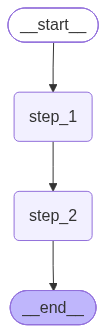

In [52]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

### **2.4 Invoke the Graph**

Call .invoke() by passing an initial state dictionary. The graph processes the input sequentially across nodes and returns the final state snapshot.

In [53]:
result = workflow.invoke({"name": "Tom"})

#1 - Current state: {'name': 'Tom'}
#2 - Current state: {'name': 'Tom', 'assigned_number': 14}
Hello Tom, your assigned number is 14


In [54]:
# The workflow invocation returns the latest state
print(result)

{'name': 'Tom', 'assigned_number': 14}
